# DATA 230 Group Project: Preliminary ML Diagnostics

This notebook implements the analyses listed in `docs/ml_direction.md`, Section 9. It trains no model. It reads the shared cleaned table produced by `notebooks/00_sm_cleaning_local.ipynb` through the team's cleaning module, `src/cleaning/us_accidents_cleaning.py`.

## 1. Introduction and research objectives

The target is `Severity` (1–4), treated as four-class classification. Three questions affect validation design and model choice before any model is trained:

| Figure | Question | Decision it informs | Status |
|---|---|---|---|
| 1 | Is the temporal label shift partly provider-specific? | What the chronological holdout measures; per-Source reporting | Required |
| 2 | Are feature–Severity relationships nonlinear? | Transformations or tree models beyond Multinomial Logistic Regression | Required |
| 3 | Do regions differ beyond the temporal shift? | Whether region-level evaluation is needed | Optional |

**Data state.** The shared cleaned table: duplicates removed, invalid readings masked, not imputed. It is not the model-ready representation; that is built later by `uc.build_model_frame()` with the training-only imputation statistics.

**Fields used so far.** `Severity` (target), `Source`, `Start_Year`, `Start_Month` (label-process) and `Split_Time` (split). They support diagnostics only and are not model inputs.

## 2. Imports and configuration

Paths are resolved from the repository root, so the notebook runs from any folder inside the repository.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import pyarrow.parquet as pq
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, PercentFormatter


NOTEBOOK_NAME = "03_preliminary_ml.ipynb"


def find_repo_root() -> Path:
    """Repository root: the folder holding both the cleaning module and notebooks/<this notebook>.

    Starts from the notebook's own folder when the editor exposes it (VS Code: __vsc_ipynb_file__;
    JupyterLab: JPY_SESSION_NAME), otherwise from the working directory. Requiring this notebook
    rules out the parquet worktree, which also contains src/cleaning but not this file."""
    hints = [globals().get("__vsc_ipynb_file__"), os.environ.get("JPY_SESSION_NAME")]
    starts = [Path(h).resolve().parent for h in hints if h and Path(h).is_file()] + [Path.cwd().resolve()]
    for start in starts:
        for folder in [start, *start.parents]:
            if (folder / "src" / "cleaning" / "us_accidents_cleaning.py").is_file() and (
                folder / "notebooks" / NOTEBOOK_NAME
            ).is_file():
                return folder
    raise FileNotFoundError(f"Cannot locate the repository root containing notebooks/{NOTEBOOK_NAME}.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "src" / "cleaning"))
import us_accidents_cleaning as uc  # team cleaning module: loaders and column roles

PROCESSED_DIR = REPO_ROOT / "data" / "processed"  # committed cleaning artifacts
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
DIAGNOSTIC_COLUMNS = ["Severity", "Source", "Start_Year", "Start_Month", "Split_Time"]
EXPECTED_PARTS = 31

print(f"pandas {pd.__version__} | pyarrow {pyarrow.__version__} | cleaning pipeline {uc.PIPELINE_VERSION}")

pandas 2.2.2 | pyarrow 11.0.0 | cleaning pipeline 3.2


## 3. Connection to the cleaned dataset

The cleaned parquet parts are on `origin/saida/cleaned-parquet` (PR #5), not on this branch. The notebook looks for them in this order:

1. the folder in the `US_ACCIDENTS_CLEAN_DIR` environment variable, if set;
2. `data/processed/us_accidents_clean/` in this repository, available once PR #5 is merged;
3. a detached worktree next to the repository, created once with:

```bash
git fetch origin
git worktree add --detach ../team-data-visualization-parquet origin/saida/cleaned-parquet
```

The worktree checks out the parquet commit in a separate folder, so no data file is added to this branch. Every part's footer is read to confirm that all parts are present and share one schema.

In [2]:
env_dir = os.environ.get("US_ACCIDENTS_CLEAN_DIR")
CLEAN_DIR_CANDIDATES = [
    Path(env_dir) if env_dir else None,
    PROCESSED_DIR / "us_accidents_clean",
    REPO_ROOT.parent / "team-data-visualization-parquet" / "data" / "processed" / "us_accidents_clean",
]
CLEAN_DIR = next((p for p in CLEAN_DIR_CANDIDATES if p is not None and any(p.glob("part_*.parquet"))), None)
if CLEAN_DIR is None:
    raise FileNotFoundError("Cleaned parquet parts not found: set US_ACCIDENTS_CLEAN_DIR or create the worktree (Section 3).")

part_files = sorted(CLEAN_DIR.glob("part_*.parquet"))
schema = pq.read_schema(part_files[0])
part_rows = [pq.read_metadata(f).num_rows for f in part_files]
schema_differs = [f.name for f in part_files if pq.read_schema(f).names != schema.names]
missing_columns = [c for c in DIAGNOSTIC_COLUMNS if c not in schema.names]
assert not schema_differs, f"parts with a different schema: {schema_differs}"
assert not missing_columns, f"diagnostic columns missing from the schema: {missing_columns}"

print(f"Cleaned data: {os.path.relpath(CLEAN_DIR, REPO_ROOT)} | {len(part_files)} parts | "
      f"{sum(f.stat().st_size for f in part_files) / 1e6:,.0f} MB | {len(schema.names)} columns")

Cleaned data: ../team-data-visualization-parquet/data/processed/us_accidents_clean | 31 parts | 826 MB | 79 columns


The roles below come from the cleaning module (`uc.COLUMN_ROLES`) and the committed data dictionary. None of the diagnostic fields is among the model inputs returned by `uc.feature_columns()`.

In [3]:
dictionary = pd.read_csv(PROCESSED_DIR / "data_dictionary.csv").set_index("column")
model_inputs = set(uc.feature_columns())
pd.DataFrame(
    {
        "role (COLUMN_ROLES)": [uc.COLUMN_ROLES.get(c) for c in DIAGNOSTIC_COLUMNS],
        "role (data_dictionary.csv)": dictionary.loc[DIAGNOSTIC_COLUMNS, "role"].to_numpy(),
        "model input": [c in model_inputs for c in DIAGNOSTIC_COLUMNS],
    },
    index=pd.Index(DIAGNOSTIC_COLUMNS, name="column"),
)

,role (COLUMN_ROLES),role (data_dictionary.csv),model input
column,,,
Severity,target,target,False
Source,label_process,label_process,False
Start_Year,label_process,label_process,False
Start_Month,label_process,label_process,False
Split_Time,split,split,False


## 4. Dataset validation

Only the five diagnostic columns are read, with `uc.load_clean()`, which reads the parts one at a time and stores repeated text as categories. The model-input pipeline (`uc.build_model_frame()`) is not needed for these checks.

In [4]:
diag = uc.load_clean(CLEAN_DIR, columns=DIAGNOSTIC_COLUMNS)
print(f"Loaded {len(diag):,} rows x {diag.shape[1]} columns ({diag.memory_usage(deep=True).sum() / 1e6:.0f} MB in memory)")

Loaded 7,610,699 rows x 5 columns (53 MB in memory)


Each check compares an observed value with the cleaning team's committed artifacts, `data/processed/report_numbers.csv` and `data/processed/data_dictionary.csv`. Missing-value references come from the dictionary's missing percentage. The holdout checks confirm that `Split_Time` separates months at the documented boundary. Any mismatch stops the notebook rather than being corrected here.

In [5]:
report = pd.read_csv(PROCESSED_DIR / "report_numbers.csv", index_col=0)["value"]


def as_int(text) -> int:
    return int(str(text).replace(",", "").strip())


n_ref = as_int(report["rows after cleaning"])
train_ref, test_ref = (as_int(x) for x in report["time split: train / test rows"].split("/"))
holdout_start = pd.Timestamp(report["time split: hold-out starts"])
start_ym = holdout_start.year * 100 + holdout_start.month

year_month = diag["Start_Year"].astype("int32") * 100 + diag["Start_Month"].astype("int32")
is_holdout = diag["Split_Time"].eq("test")
severity_counts = diag["Severity"].value_counts()
split_counts = diag["Split_Time"].value_counts()

checks = [
    ("Parquet parts", EXPECTED_PARTS, len(part_files)),
    ("Columns", len(dictionary), len(schema.names)),
    ("Rows (part footers)", n_ref, sum(part_rows)),
    ("Rows (loaded)", n_ref, len(diag)),
    *[(f"Severity {k}", as_int(report[f"Severity {k} after cleaning"]), int(severity_counts.get(k, 0))) for k in (1, 2, 3, 4)],
    ("Split_Time train", train_ref, int(split_counts.get("train", 0))),
    ("Split_Time holdout", test_ref, int(split_counts.get("test", 0))),
    ("Holdout rows before the holdout month", 0, int((year_month[is_holdout] < start_ym).sum())),
    ("Train rows in or after the holdout month", 0, int((year_month[~is_holdout] >= start_ym).sum())),
    *[(f"Missing: {c}", round(dictionary.loc[c, "missing %"] * n_ref / 100), int(diag[c].isna().sum())) for c in DIAGNOSTIC_COLUMNS],
    *[(f"Distinct: {c}", int(dictionary.loc[c, "distinct"]), int(diag[c].nunique())) for c in DIAGNOSTIC_COLUMNS],
]
validation = pd.DataFrame(checks, columns=["check", "committed artifact", "observed"]).set_index("check")
validation["match"] = validation["committed artifact"].eq(validation["observed"])
display(validation)

mismatches = validation.index[~validation["match"]].tolist()
assert not mismatches, f"Mismatch with the committed cleaning artifacts: {mismatches}"

,committed artifact,observed,match
check,,,
Parquet parts,31,31,True
Columns,79,79,True
Rows (part footers),7610699,7610699,True
Rows (loaded),7610699,7610699,True
Severity 1,65570,65570,True
Severity 2,6048391,6048391,True
Severity 3,1295235,1295235,True
Severity 4,201503,201503,True
Split_Time train,6248916,6248916,True


The committed artifacts record the number of providers (3) but not their row counts, so the Source distribution has no reference value. It is shown here for context only.

In [6]:
source_rows = diag["Source"].astype("string").value_counts().sort_index()
pd.DataFrame({"rows": source_rows, "share (%)": (100 * source_rows / source_rows.sum()).round(2)})

,rows,share (%)
Source,,
Source1,4210136,55.32
Source2,3303245,43.4
Source3,97318,1.28


## 5. Figure 1: Severity mix by Source over time

**Question.** Is the temporal shift in Severity partly provider-specific, and what does that imply for the chronological holdout?

**Method.** For every calendar month and `Source`, the share of that Source's rows at each Severity level, P(Severity = k | Source, month). Shares are not smoothed. A Source-month with no rows stays missing rather than zero, so lines are never interpolated across it. Months with fewer than 100 rows for a Source are left blank, by the same rule for every Source.

### 5.1 Monthly aggregation

In [7]:
SEVERITY_LEVELS = [1, 2, 3, 4]
SOURCES = ["Source1", "Source2", "Source3"]
MIN_ROWS_PER_MONTH = 100  # same rule for every Source; smaller months are left blank in Figure 1

# Rows per Source, month and Severity. A Severity level absent from an observed Source-month is a
# real zero; a Source-month with no rows does not appear at all and stays missing.
counts = (
    diag.groupby(["Source", "Start_Year", "Start_Month", "Severity"], observed=True)
    .size()
    .unstack("Severity", fill_value=0)
    .reindex(columns=SEVERITY_LEVELS, fill_value=0)
)
month_start = pd.to_datetime(
    pd.DataFrame(
        {
            "year": counts.index.get_level_values("Start_Year").astype(int),
            "month": counts.index.get_level_values("Start_Month").astype(int),
            "day": 1,
        }
    )
)
counts.index = pd.MultiIndex.from_arrays(
    [counts.index.get_level_values("Source").astype(str), month_start], names=["Source", "Month"]
)
counts["rows"] = counts[SEVERITY_LEVELS].sum(axis=1)
shares = 100 * counts[SEVERITY_LEVELS].div(counts["rows"], axis=0)  # P(Severity = k | Source, month), in %

share_sum_gap = (shares.sum(axis=1) - 100).abs().max()
print(f"{len(counts)} Source-months | {counts['rows'].sum():,} rows | "
      f"largest gap between a Source-month's four shares and 100%: {share_sum_gap:.6f} percentage points")

247 Source-months | 7,610,699 rows | largest gap between a Source-month's four shares and 100%: 0.000000 percentage points


### 5.2 Checks on the aggregate

Coverage and monthly sample size for each Source, then the Severity mix of each Source in the chronological partitions. These tables support interpretation; they are not figures.

In [8]:
rows_by_month = counts["rows"]
by_source = rows_by_month.groupby(level="Source")
first_month = by_source.apply(lambda s: s.index.get_level_values("Month").min())
last_month = by_source.apply(lambda s: s.index.get_level_values("Month").max())
months_in_span = [len(pd.date_range(first_month[s], last_month[s], freq="MS")) for s in first_month.index]

coverage = pd.DataFrame(
    {
        "first month": first_month.dt.strftime("%Y-%m"),
        "last month": last_month.dt.strftime("%Y-%m"),
        "months observed": by_source.size(),
        "empty months in span": [m - n for m, n in zip(months_in_span, by_source.size())],
        "rows": by_source.sum(),
        "min rows / month": by_source.min(),
        "median rows / month": by_source.median().round().astype(int),
        f"months < {MIN_ROWS_PER_MONTH} rows": by_source.apply(lambda s: int((s < MIN_ROWS_PER_MONTH).sum())),
        f"rows in those months": by_source.apply(lambda s: int(s[s < MIN_ROWS_PER_MONTH].sum())),
    }
)
display(coverage)
assert coverage["rows"].sum() == len(diag) == n_ref, "Source totals do not add up to the cleaned row count"

,first month,last month,months observed,empty months in span,rows,min rows / month,median rows / month,months < 100 rows,rows in those months
Source,,,,,,,,,
Source1,2016-01,2023-03,87,0,4210136,7,18448,1,7
Source2,2016-02,2022-09,80,0,3303245,415,38508,0,0
Source3,2016-02,2022-09,80,0,97318,2,881,11,127


In [9]:
def severity_mix(severity_counts: pd.DataFrame) -> pd.DataFrame:
    """Rows and within-row Severity shares (%) for a table of counts with one column per level."""
    rows = severity_counts.sum(axis=1)
    mix = (100 * severity_counts.div(rows, axis=0)).round(2)
    mix.columns = [f"Severity {k} (%)" for k in SEVERITY_LEVELS]
    mix.insert(0, "rows", rows)
    return mix


partition_counts = (
    diag.groupby(["Split_Time", "Source", "Severity"], observed=True)
    .size()
    .unstack("Severity", fill_value=0)
    .reindex(columns=SEVERITY_LEVELS, fill_value=0)
)
partition_counts.index = partition_counts.index.set_levels(
    [level.astype(str) for level in partition_counts.index.levels]
)
partitions = {
    "All rows": partition_counts.groupby(level="Source").sum(),
    "Train (before May 2022)": partition_counts.loc["train"],
    "Holdout (from May 2022)": partition_counts.loc["test"],
}
mix_by_partition = pd.concat(
    {
        name: severity_mix(pd.concat([part.reindex(SOURCES, fill_value=0), part.sum().to_frame("All sources").T]))
        for name, part in partitions.items()
    },
    names=["Partition", "Source"],
)
mix_by_partition

rows  Severity 1 (%)  Severity 2 (%)  \
Partition               Source                                                 
All rows                Source1      4210136            0.63           91.17   
                        Source2      3303245            1.06           65.02   
                        Source3        97318            4.21           64.06   
                        All sources  7610699            0.86           79.47   
Train (before May 2022) Source1      2959360            0.89           88.68   
                        Source2      3200569            0.09           66.06   
                        Source3        88987            0.27           67.13   
                        All sources  6248916            0.47           76.79   
Holdout (from May 2022) Source1      1250776            0.00           97.07   
                        Source2       102676           31.21           32.49   
                        Source3         8331           46.30           31.24   
                        All sources  1361783            2.64           91.80   

                                     Severity 3 (%)  Severity 4 (%)  
Partition               Source                                       
All rows                Source1                3.76            4.44  
                        Source2               33.49            0.43  
                        Source3               31.57            0.16  
                        All sources           17.02            2.65  
Train (before May 2022) Source1                5.35            5.08  
                        Source2               33.42            0.42  
                        Source3               32.45            0.15  
                        All sources           20.11            2.63  
Holdout (from May 2022) Source1                0.00            2.93  
                        Source2               35.56            0.74  
                        Source3               22.28            0.18  
                        All sources            2.82            2.75

### 5.3 Figure 1

Each panel has its own y-axis range. Months with fewer than 100 rows for a Source are left blank (Source1: 1 month; Source3: 11 months; Section 5.2), and lines are not interpolated across them. Source3 holds 1.28% of rows, so it is drawn with less emphasis and its line should be read cautiously.

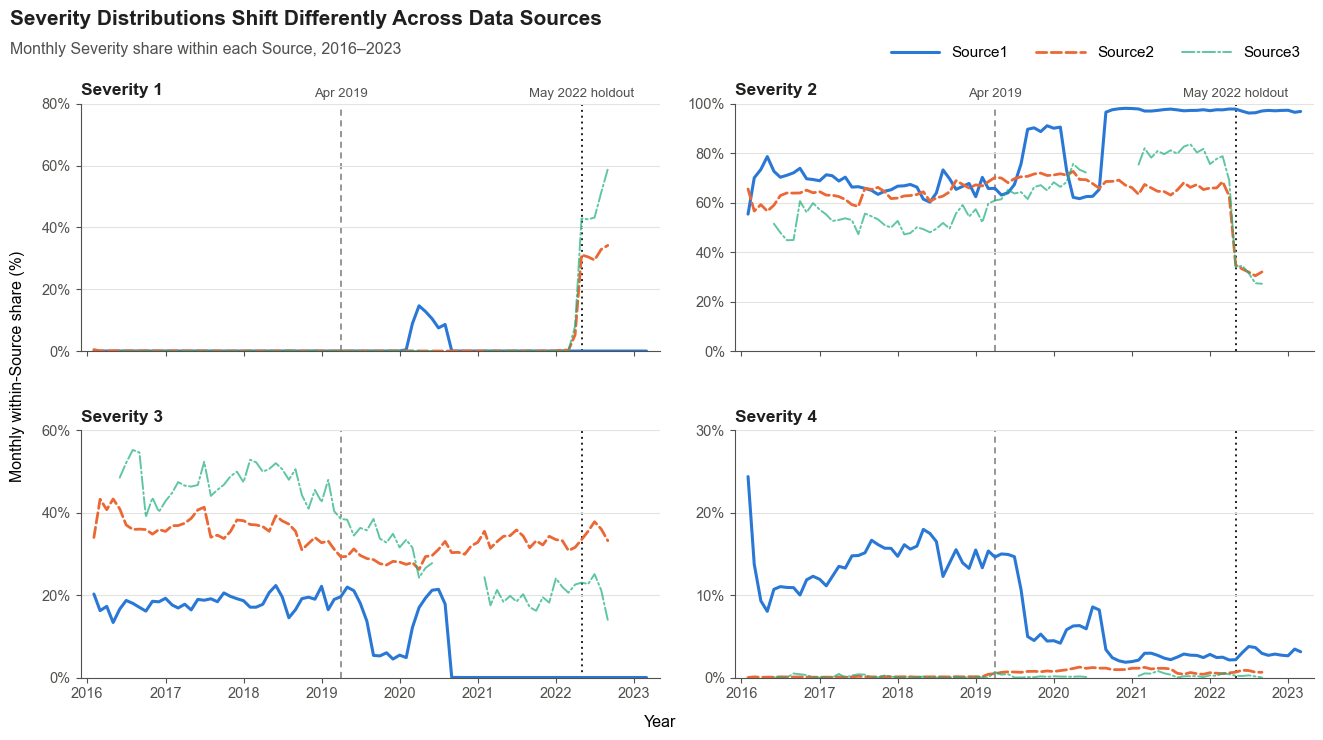

In [10]:
# Fixed identity per Source in every panel: colour plus line style, so the figure also reads in grayscale.
# Source3 (1.28% of rows) is drawn thinner and lighter so it does not compete with Source1 and Source2.
SOURCE_STYLE = {
    "Source1": {"color": "#2a78d6", "linestyle": "-", "linewidth": 2.2, "alpha": 1.0},
    "Source2": {"color": "#eb6834", "linestyle": "--", "linewidth": 2.0, "alpha": 1.0},
    "Source3": {"color": "#1baf7a", "linestyle": "-.", "linewidth": 1.4, "alpha": 0.7},
}
WEATHER_CHANGE = pd.Timestamp(uc.WEATHER_FEED_CHANGE)
REFERENCE_LINES = [
    (WEATHER_CHANGE, "Apr 2019", {"color": "#7a7974", "linestyle": (0, (4, 3)), "linewidth": 1.1}),
    (holdout_start, "May 2022 holdout", {"color": "#1f1f1e", "linestyle": (0, (1, 2)), "linewidth": 1.4}),
]

calendar = pd.date_range(counts.index.get_level_values("Month").min(), counts.index.get_level_values("Month").max(), freq="MS")
rows_wide = counts["rows"].unstack("Source").reindex(index=calendar, columns=SOURCES)

plot_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#52514e",
    "axes.labelcolor": "#1f1f1e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
}
with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(2, 2, figsize=(13.33, 7.5), sharex=True)
    for ax, level in zip(axes.flat, SEVERITY_LEVELS):
        level_share = shares[level].unstack("Source").reindex(index=calendar, columns=SOURCES)
        level_share = level_share.where(rows_wide >= MIN_ROWS_PER_MONTH)  # blank, never interpolated
        for source in SOURCES:
            ax.plot(level_share.index, level_share[source], label=source,
                    solid_capstyle="round", dash_capstyle="round", **SOURCE_STYLE[source])
        for when, _, ref_style in REFERENCE_LINES:
            ax.axvline(when, zorder=0, **ref_style)
        ax.set_title(f"Severity {level}", loc="left", fontsize=12.5, fontweight="bold", color="#1f1f1e")
        headroom_peak = min(level_share.max().max() * 1.04, 100)  # a share never exceeds 100%
        ticks = MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]).tick_values(0, headroom_peak)
        y_top = ticks[ticks >= headroom_peak].min()  # end each axis on a labelled round tick
        ax.set_ylim(0, y_top)
        ax.set_yticks(ticks[ticks <= y_top])
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.grid(axis="y", color="#e4e3df", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=10.5)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[0, 0].set_xlim(calendar.min() - pd.DateOffset(months=1), calendar.max() + pd.DateOffset(months=2))
    for ax in axes[1]:
        ax.tick_params(axis="x", labelbottom=True)
    for ax in axes[0]:  # short reference labels once, above the top row; the panels share the x-axis
        for when, label, _ in REFERENCE_LINES:
            ax.text(when, 1.015, label, transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=9.5, color="#52514e")

    fig.supxlabel("Year", fontsize=11.5, y=0.015)
    fig.supylabel("Monthly within-Source share (%)", x=0.012, fontsize=11.5)
    fig.text(0.012, 0.975, "Severity Distributions Shift Differently Across Data Sources",
             fontsize=15, fontweight="bold", color="#1f1f1e", va="top")
    fig.text(0.012, 0.932, "Monthly Severity share within each Source, 2016–2023",
             fontsize=11.5, color="#52514e", va="top")
    fig.legend(handles=axes[0, 0].get_legend_handles_labels()[0], loc="upper right", ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.99, 0.945), handlelength=3.2, columnspacing=1.8)
    fig.subplots_adjust(left=0.065, right=0.99, top=0.85, bottom=0.085, hspace=0.32, wspace=0.13)

    FIGURE_1_PATH = FIGURES_DIR / "ml_severity_source_over_time.png"
    fig.savefig(FIGURE_1_PATH, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()

### 5.4 Key quantitative findings

Annual within-Source Severity shares for selected years (a Source appears only in years with data), then the composition of the chronological holdout.

In [11]:
ANNUAL_YEARS = [2016, 2020, 2021, 2022, 2023]
annual_counts = counts[SEVERITY_LEVELS].groupby(
    [counts.index.get_level_values("Source"), counts.index.get_level_values("Month").year.rename("Year")]
).sum()
annual_mix = severity_mix(annual_counts[annual_counts.index.get_level_values("Year").isin(ANNUAL_YEARS)])
annual_mix

rows  Severity 1 (%)  Severity 2 (%)  Severity 3 (%)  \
Source  Year                                                            
Source1 2016   128763            0.00           71.60           17.40   
        2020   630941            4.19           85.14            6.86   
        2021  1098221            0.00           97.53            0.00   
        2022  1510274            0.00           97.23            0.00   
        2023   245191            0.00           97.12            0.00   
Source2 2016   279620            0.08           63.07           36.79   
        2020   448013            0.04           69.32           29.64   
        2021   431136            0.03           65.63           33.50   
        2022   219250           15.41           50.14           33.82   
Source3 2016     1594            0.00           52.51           47.30   
        2020    21922            0.04           70.26           29.59   
        2021    18580            0.05           80.47           19.22   
        2022    16763           24.27           53.18           22.28   

              Severity 4 (%)  
Source  Year                  
Source1 2016           11.00  
        2020            3.81  
        2021            2.47  
        2022            2.77  
        2023            2.88  
Source2 2016            0.06  
        2020            1.00  
        2021            0.84  
        2022            0.63  
Source3 2016            0.19  
        2020            0.11  
        2021            0.26  
        2022            0.26

In [12]:
holdout_by_source = partition_counts.loc["test"].reindex(SOURCES, fill_value=0)
holdout_composition = holdout_by_source.copy()
holdout_composition.columns = [f"Severity {k} rows" for k in SEVERITY_LEVELS]
holdout_composition.insert(0, "holdout rows", holdout_by_source.sum(axis=1))
holdout_composition.insert(1, "share of holdout (%)",
                           (100 * holdout_composition["holdout rows"] / holdout_composition["holdout rows"].sum()).round(2))
holdout_composition.loc["All sources"] = holdout_composition.sum()
holdout_composition = holdout_composition.astype({c: "int64" for c in holdout_composition.columns if c != "share of holdout (%)"})
holdout_composition

,holdout rows,share of holdout (%),Severity 1 rows,Severity 2 rows,Severity 3 rows,Severity 4 rows
Source,,,,,,
Source1,1250776,91.85,0,1214122,0,36654
Source2,102676,7.54,32041,33356,36515,764
Source3,8331,0.61,3857,2603,1856,15
All sources,1361783,100.00,35898,1250081,38371,37433


### Figure 1 interpretation

- **Label mix differs by provider.** *Data:* Source1's Severity 3 share falls from 17.40% (2016) to 6.86% (2020) and is 0.00% in 2021, 2022 and 2023. Its Severity 4 share falls from 11.00% to 2.47–2.88%, and among the selected years its only Severity 1 records are in 2020 (4.19%). Source2's Severity 1 share is 0.03–0.08% in 2016–2021 and 15.41% in 2022, while its Severity 3 share stays between 29.64% and 36.79%. *Interpretation:* consistent with provider-specific label regimes; part of the temporal shift in cleaning Figure 5 is associated with Source composition, not only with changes in accidents.
- **The holdout changes provider composition.** *Data:* Source1 supplies 2,959,360 of 6,248,916 training rows but 1,250,776 of 1,361,783 holdout rows (91.85%), and none of its holdout rows is Severity 1 or 3. All 35,898 Severity 1 and 38,371 Severity 3 holdout rows come from Source2 and Source3 (7.54% + 0.61% of holdout rows). *Interpretation:* an overall holdout metric would mostly reflect Source1, while recall for Severity 1 and 3 would be measured only on the other two providers, so pooled metrics can hide provider-specific behavior.
- **`Source` belongs in evaluation, not automatically in the predictors.** *Interpretation:* holdout results should be reported overall and per Source. As a predictor, `Source` would let a model learn provider-specific labelling patterns (for example, that recent Source1 records are never Severity 3) rather than accident conditions; including it remains the team's label-process decision.
- **Training-period class proportions do not match the holdout.** *Data:* all-source shares are 0.47 / 76.79 / 20.11 / 2.63% (Severity 1–4) in the training partition and 2.64 / 91.80 / 2.82 / 2.75% in the holdout. *Interpretation:* class weights derived from training proportions will not match the holdout, so Macro F1, per-class recall and the confusion matrix are needed to see how each class is affected.
- **Caution for Source3.** *Data:* Source3 has 97,318 rows; its median month has 881 rows, and 11 of its 80 months have fewer than 100 rows (127 rows in total), which are left blank. *Interpretation:* its monthly line is noisier and is treated as supporting evidence only; the conclusions above rest mainly on Source1 and Source2.

## 6. Figure 2: Nonlinear feature–Severity relationships

**Question.** Are the relationships between the continuous weather predictors and the four-class Severity target nonlinear enough that a purely linear Multinomial Logistic Regression specification may be inadequate? This is a functional-form diagnostic, not model training.

**Method.**
- Chronological training partition only (`Split_Time == "train"`); the holdout is not inspected.
- Source1 and Source2 are analysed separately, because Figure 1 shows different label regimes.
- Each feature is binned, and each Source × bin gets the empirical multinomial log-odds log[P(Severity = k) / P(Severity = 2)] for k = 1, 3, 4. Before taking logs, 0.5 is added to every class count (Haldane–Anscombe correction), so a zero count never produces an infinite value.
- A straight line, weighted by bin size, is fitted to each set of binned log-odds as a descriptive reference only. Weighted R² and RMSE summarise how far the bins depart from it.
- Rows missing a feature are excluded for that feature only; values are the cleaned, non-imputed ones.

`Weather_Period`, a label-process field from the cleaning pipeline, is also loaded. It is used only to check whether a pattern follows the April 2019 recording change (Section 6.4), never as a predictor.

### 6.1 Training data and Source sample sizes

In [13]:
FEATURES = {  # cleaned column -> axis label
    "Temperature(F)": "Temperature (°F)",
    "Visibility(mi)": "Visibility (mi)",
    "Wind_Speed(mph)": "Wind speed (mph)",
    "Humidity(%)": "Humidity (%)",
}
FIG2_SOURCES = ["Source1", "Source2"]
CONTRASTS = [1, 3, 4]  # each compared with Severity 2
ZERO_CORRECTION = 0.5  # Haldane–Anscombe: added to every class count before taking logs

weather = uc.load_clean(
    CLEAN_DIR, columns=["Severity", "Source", "Split_Time", "Weather_Period", "Start_Hour", *FEATURES]
)
weather = weather[weather["Split_Time"].eq("train")].reset_index(drop=True)  # holdout is never inspected
weather["Source"] = weather["Source"].astype("string")
weather["Before_Apr_2019"] = weather["Weather_Period"].astype("string").eq("Before Apr 2019")

pd.DataFrame(
    {
        "training rows": weather["Source"].value_counts(),
        **{f"missing {c} (%)": (100 * weather[c].isna().groupby(weather["Source"]).mean()).round(2) for c in FEATURES},
    }
).reindex(SOURCES)

,training rows,missing Temperature(F) (%),missing Visibility(mi) (%),missing Wind_Speed(mph) (%),missing Humidity(%) (%)
Source,,,,,
Source1,2959360,2.44,2.54,5.58,2.57
Source2,3200569,1.67,1.93,11.08,1.78
Source3,88987,2.16,2.07,6.83,2.27


### 6.2 Binning

- **Temperature:** quantiles of the pooled Source1 + Source2 training rows, rounded to whole °F, with finer tails (2% and 5%) so that cold and heat extremes keep their own bins.
- **Humidity:** quantiles in the same way (5% lower tail, then deciles).
- **Wind speed:** 12% of values are exactly 0 (calm) and the right tail is long, so calm gets its own bin, the middle uses fixed steps, and everything above 25 mph is pooled.
- **Visibility:** 80% of values are exactly 10 miles, so quantiles would collapse. Fixed bins keep the low-visibility ranges, exactly 10 miles, and above 10 miles separate.

The same edges are used for every Source. The plotted x position of a bin is the median feature value of that Source's rows in the bin.

In [14]:
def quantile_edges(values: pd.Series, probs: list[float]) -> np.ndarray:
    """Quantile cut points rounded to whole units, with open-ended outer bins."""
    edges = np.unique(np.round(values.dropna().quantile(probs).to_numpy()))
    edges[0], edges[-1] = -np.inf, np.inf
    return edges


def bin_label(interval: pd.Interval) -> str:
    if np.isinf(interval.left):
        return f"≤ {interval.right:g}"
    if np.isinf(interval.right):
        return f"> {interval.left:g}"
    return f"({interval.left:g}, {interval.right:g}]"


pooled = weather[weather["Source"].isin(FIG2_SOURCES)]
BIN_EDGES = {
    "Temperature(F)": quantile_edges(pooled["Temperature(F)"], [0, .02, .05, .1, .2, .3, .4, .5, .6, .7, .8, .9, .95, .98, 1]),
    "Visibility(mi)": np.array([-np.inf, 0.5, 1, 2, 3, 5, 7, 9.99, 10, np.inf]),
    "Wind_Speed(mph)": np.array([-np.inf, 0, 3, 5, 7, 9, 11, 14, 17, 20, 25, np.inf]),
    "Humidity(%)": quantile_edges(pooled["Humidity(%)"], [0, .05, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]),
}


def binned_log_odds(frame: pd.DataFrame, features=tuple(FEATURES)) -> pd.DataFrame:
    """Class counts, shares (%), median feature value and log-odds vs Severity 2 per feature x Source x bin."""
    pieces = {}
    for feature in features:
        rows = frame[["Source", "Severity", feature]].dropna(subset=[feature])
        rows = rows.assign(bin=pd.cut(rows[feature], BIN_EDGES[feature], right=True))
        table = (
            rows.groupby(["Source", "bin", "Severity"], observed=True).size()
            .unstack("Severity", fill_value=0).reindex(columns=SEVERITY_LEVELS, fill_value=0)
        )
        table["rows"] = table[SEVERITY_LEVELS].sum(axis=1)
        table["representative"] = rows.groupby(["Source", "bin"], observed=True)[feature].median()
        pieces[feature] = table
    stats = pd.concat(pieces, names=["feature"])
    for k in SEVERITY_LEVELS:
        stats[f"share {k} (%)"] = 100 * stats[k] / stats["rows"]
    for k in CONTRASTS:
        stats[f"log-odds {k} vs 2"] = np.log((stats[k] + ZERO_CORRECTION) / (stats[2] + ZERO_CORRECTION))
    return stats


bin_stats = binned_log_odds(weather)
main_bins = bin_stats[bin_stats.index.get_level_values("Source").isin(FIG2_SOURCES)]
share_gap = (bin_stats[[f"share {k} (%)" for k in SEVERITY_LEVELS]].sum(axis=1) - 100).abs().max()
print(f"Source1/Source2: {len(main_bins)} feature x Source x bin cells | smallest bin {main_bins['rows'].min():,} rows | "
      f"cells with a zero class count: {int((main_bins[SEVERITY_LEVELS] == 0).any(axis=1).sum())} | "
      f"largest gap between class shares and 100%: {share_gap:.6f} percentage points")

source_rows = bin_stats["rows"].unstack("Source")
bin_validation = pd.DataFrame(
    {
        "Source1 rows": source_rows["Source1"],
        "Source2 rows": source_rows["Source2"],
        "Source1 plotted at": bin_stats["representative"].unstack("Source")["Source1"],
        "Source2 plotted at": bin_stats["representative"].unstack("Source")["Source2"],
        "Source3 rows": source_rows["Source3"],
        "Source3 smallest class count": bin_stats.xs("Source3", level="Source")[SEVERITY_LEVELS].min(axis=1),
    }
).reindex(list(FEATURES), level="feature")
bin_validation.index = pd.MultiIndex.from_tuples(
    [(feature, bin_label(interval)) for feature, interval in bin_validation.index], names=["feature", "bin"]
)
bin_validation.astype({c: "Int64" for c in bin_validation.columns if "plotted" not in c})

Source1/Source2: 90 feature x Source x bin cells | smallest bin 11,795 rows | cells with a zero class count: 0 | largest gap between class shares and 100%: 0.000000 percentage points


Source1 rows  Source2 rows  Source1 plotted at  \
feature         bin                                                          
Temperature(F)  ≤ 19               68264         55039           13.000000   
                (19, 28]          106827         95821           25.000000   
                (28, 34]          140027        136936           32.000000   
                (34, 45]          316375        330989           41.000000   
                (45, 52]          302020        299986           49.000000   
                (52, 58]          304495        316496           55.000000   
                (58, 63]          276551        302624           61.000000   
                (63, 68]          280972        319978           66.000000   
                (68, 73]          290730        333803           71.000000   
                (73, 78]          271293        305116           76.000000   
                (78, 84]          288855        337772           81.000000   
                (84, 88]          120281        148317           86.000000   
                (88, 92]           70656         93974           90.000000   
                > 92               49930         70280           95.000000   
Visibility(mi)  ≤ 0.5              34860         33439            0.250000   
                (0.5, 1]           55531         44703            1.000000   
                (1, 2]             53472         65033            2.000000   
                (2, 3]             48209         64424            3.000000   
                (3, 5]             98100        115605            5.000000   
                (5, 7]            126279        154415            7.000000   
                (7, 9.99]         123586        154537            9.000000   
                (9.99, 10]       2332216       2492067           10.000000   
                > 10               11795         14645           15.000000   
Wind_Speed(mph) ≤ 0               428384        267071            0.000000   
                (0, 3]            223234        146464            3.000000   
                (3, 5]            320094        478211            5.000000   
                (5, 7]            523603        605831            6.000000   
                (7, 9]            403068        366829            8.100000   
                (9, 11]           214673        309971           10.000000   
                (11, 14]          375570        385204           13.000000   
                (14, 17]          173907        151650           16.000000   
                (17, 20]           66206         77558           18.000000   
                (20, 25]           51435         45029           22.000000   
                > 25               14063         12015           28.799999   
Humidity(%)     ≤ 24              189912        136955           18.000000   
                (24, 32]          150969        136439           29.000000   
                (32, 44]          314508        321615           39.000000   
                (44, 52]          273139        287510           49.000000   
                (52, 60]          310213        321403           57.000000   
                (60, 67]          288185        304718           64.000000   
                (67, 74]          283803        315935           71.000000   
                (74, 81]          290291        326427           78.000000   
                (81, 87]          276744        323335           85.000000   
                (87, 93]          288510        356070           90.000000   
                > 93              217078        313167           97.000000   

                            Source2 plotted at  Source3 rows  \
feature         bin                                            
Temperature(F)  ≤ 19                 13.000000          1325   
                (19, 28]             25.000000          2053   
                (28, 34]             32.000000          2897   
                (34, 45]             41.0

**Source3 is omitted from the figure.** It has 88,987 training rows, but its Severity 1 and Severity 4 counts are below 10 in most bins (last column above), so its bin-level log-odds would be dominated by sampling noise. Its counts stay in the table for transparency.

### 6.3 Straight-line reference and linearity diagnostics

For every Source × feature × contrast, a straight line weighted by bin size is fitted to the binned log-odds. Weighted R² close to 1 means the bins sit close to a straight line. A low R² can mean either curvature or a flat relationship with noise, so the log-odds range (largest minus smallest bin) is shown alongside it. These are descriptive summaries, not tests.

In [15]:
def weighted_line(x: np.ndarray, y: np.ndarray, w: np.ndarray):
    """Weighted least-squares straight line: fitted values, weighted R² and weighted RMSE."""
    design = np.column_stack([np.ones_like(x), x])
    root_w = np.sqrt(w)
    coef, *_ = np.linalg.lstsq(design * root_w[:, None], y * root_w, rcond=None)
    fitted = design @ coef
    residual_ss = np.sum(w * (y - fitted) ** 2)
    total_ss = np.sum(w * (y - np.average(y, weights=w)) ** 2)
    return fitted, 1 - residual_ss / total_ss, np.sqrt(residual_ss / w.sum())


def linearity_diagnostics(stats: pd.DataFrame) -> pd.DataFrame:
    """Adds the straight-line fit to `stats` (in place) and returns one row per feature x Source x contrast."""
    records = []
    for (feature, source), part in stats.groupby(level=["feature", "Source"], sort=False):
        if source not in FIG2_SOURCES:
            continue
        x = part["representative"].to_numpy(float)
        w = part["rows"].to_numpy(float)
        for k in CONTRASTS:
            y = part[f"log-odds {k} vs 2"].to_numpy(float)
            fitted, r2, rmse = weighted_line(x, y, w)
            stats.loc[part.index, f"line {k} vs 2"] = fitted
            records.append({"feature": feature, "contrast": f"Severity {k} vs 2", "Source": source,
                            "log-odds range": y.max() - y.min(), "weighted RMSE": rmse, "weighted R²": r2})
    return pd.DataFrame(records)


diagnostics = linearity_diagnostics(bin_stats)
linearity = diagnostics.pivot_table(index=["feature", "contrast"], columns="Source",
                                    values=["log-odds range", "weighted RMSE", "weighted R²"], sort=False)
linearity = linearity.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
linearity.round(2)

Source                                 Source1                            \
                                log-odds range weighted RMSE weighted R²   
feature         contrast                                                   
Temperature(F)  Severity 1 vs 2           5.38          0.42        0.80   
                Severity 3 vs 2           0.39          0.07        0.58   
                Severity 4 vs 2           0.71          0.10        0.70   
Visibility(mi)  Severity 1 vs 2           1.33          0.12        0.81   
                Severity 3 vs 2           1.99          0.13        0.04   
                Severity 4 vs 2           0.84          0.07        0.10   
Wind_Speed(mph) Severity 1 vs 2           0.69          0.16        0.45   
                Severity 3 vs 2           1.76          0.41        0.49   
                Severity 4 vs 2           0.86          0.21        0.18   
Humidity(%)     Severity 1 vs 2           1.78          0.25        0.68   
                Severity 3 vs 2           0.47          0.09        0.20   
                Severity 4 vs 2           0.91          0.09        0.81   

Source                                 Source2                            
                                log-odds range weighted RMSE weighted R²  
feature         contrast                                                  
Temperature(F)  Severity 1 vs 2           1.12          0.37        0.02  
                Severity 3 vs 2           0.49          0.07        0.03  
                Severity 4 vs 2           0.86          0.12        0.02  
Visibility(mi)  Severity 1 vs 2           0.78          0.11        0.71  
                Severity 3 vs 2           0.47          0.05        0.18  
                Severity 4 vs 2           0.99          0.06        0.40  
Wind_Speed(mph) Severity 1 vs 2           0.64          0.15        0.14  
                Severity 3 vs 2           0.52          0.07        0.70  
                Severity 4 vs 2           0.96          0.29        0.04  
Humidity(%)     Severity 1 vs 2           0.86          0.08        0.87  
                Severity 3 vs 2           0.19          0.04        0.55  
                Severity 4 vs 2           0.41          0.04        0.84

### 6.4 Recording-period check

Figure 1 marks an April 2019 weather-feed change. Wind speed was recorded with decimals before it (converted units) and as whole numbers after it, so different wind bins mix the two periods in different proportions. In Source1, whose label mix changed over the same years, that can create a pattern across bins that follows the period rather than the wind. The table shows each bin's share of rows recorded before April 2019, the Severity 3 log-odds from all training rows, and the same log-odds from training rows recorded from April 2019 onward. The last table repeats the straight-line R² within those later rows for every feature.

In [16]:
wind = weather.dropna(subset=["Wind_Speed(mph)"])
decimal_share = (100 * (wind["Wind_Speed(mph)"] % 1 != 0).groupby(wind["Before_Apr_2019"]).mean()).round(1)
print(f"Wind speed values with decimals: {decimal_share[True]}% before April 2019, {decimal_share[False]}% from April 2019")

bin_stats_later = binned_log_odds(weather[~weather["Before_Apr_2019"]])
wind_bins = pd.cut(wind["Wind_Speed(mph)"], BIN_EDGES["Wind_Speed(mph)"], right=True)
pre_share = 100 * wind["Before_Apr_2019"].groupby([wind["Source"], wind_bins], observed=True).mean()
wind_check = pd.concat(
    {
        source: pd.DataFrame(
            {
                "rows before Apr 2019 (%)": pre_share.loc[source],
                "Severity 3 log-odds, all training rows": bin_stats.loc[("Wind_Speed(mph)", source), "log-odds 3 vs 2"],
                "Severity 3 log-odds, from Apr 2019": bin_stats_later.loc[("Wind_Speed(mph)", source), "log-odds 3 vs 2"],
            }
        )
        for source in FIG2_SOURCES
    },
    axis=1,
)
wind_check.index = [bin_label(interval) for interval in wind_check.index]
wind_check.index.name = "wind speed bin (mph)"
display(wind_check.round(2))

r2_later = linearity_diagnostics(bin_stats_later).pivot_table(
    index=["feature", "contrast"], columns="Source", values="weighted R²", sort=False
)
pd.concat({"all training rows": linearity.xs("weighted R²", axis=1, level=1), "from Apr 2019 only": r2_later},
          axis=1).round(2)

Wind speed values with decimals: 95.6% before April 2019, 0.0% from April 2019


Source1  \
                     rows before Apr 2019 (%)   
wind speed bin (mph)                            
≤ 0                                      0.33   
(0, 3]                                   0.47   
(3, 5]                                  28.39   
(5, 7]                                  17.72   
(7, 9]                                  10.48   
(9, 11]                                 32.27   
(11, 14]                                18.29   
(14, 17]                                13.96   
(17, 20]                                27.93   
(20, 25]                                16.62   
> 25                                     22.9   

                                                             \
                     Severity 3 log-odds, all training rows   
wind speed bin (mph)                                          
≤ 0                                                   -4.08   
(0, 3]                                                -3.80   
(3, 5]                                                -2.57   
(5, 7]                                                -2.80   
(7, 9]                                                -2.96   
(9, 11]                                               -2.31   
(11, 14]                                              -2.64   
(14, 17]                                              -2.77   
(17, 20]                                              -2.37   
(20, 25]                                              -2.70   
> 25                                                  -2.58   

                                                         \
                     Severity 3 log-odds, from Apr 2019   
wind speed bin (mph)                                      
≤ 0                                               -4.10   
(0, 3]                                            -3.83   
(3, 5]                                            -3.71   
(5, 7]                                            -3.57   
(7, 9]                                            -3.42   
(9, 11]                                           -3.33   
(11, 14]                                          -3.29   
(14, 17]                                          -3.30   
(17, 20]                                          -3.25   
(20, 25]                                          -3.31   
> 25                                              -3.33   

                                      Source2  \
                     rows before Apr 2019 (%)   
wind speed bin (mph)                            
≤ 0                                      1.07   
(0, 3]                                   1.73   
(3, 5]                                  68.45   
(5, 7]                                  53.38   
(7, 9]                                  38.08   
(9, 11]                                 71.88   
(11, 14]                                53.71   
(14, 17]                                46.29   
(17, 20]                                67.43   
(20, 25]                                51.31   
> 25                                    62.18   

                                                             \
                     Severity 3 log-odds, all training rows   
wind speed bin (mph)                                          
≤ 0                                                   -1.04   
(0, 3]                                                -0.93   
(3, 5]                                                -0.71   
(5, 7]                                                -0.71   
(7, 9]                                                -0.67   
(9, 11]                                               -0.59   
(11, 14]                                              -0.58   
(14, 17]                                              -0.56   
(17, 20]                                              -0.54   
(20, 25]                                              -0.55   
> 25                                                  -0.51   

                                                         
             

all training rows         from Apr 2019 only  \
Source                                    Source1 Source2            Source1   
feature         contrast                                                       
Temperature(F)  Severity 1 vs 2              0.80    0.02               0.81   
                Severity 3 vs 2              0.58    0.03               0.87   
                Severity 4 vs 2              0.70    0.02               0.62   
Visibility(mi)  Severity 1 vs 2              0.81    0.71               0.82   
                Severity 3 vs 2              0.04    0.18               0.08   
                Severity 4 vs 2              0.10    0.40               0.03   
Wind_Speed(mph) Severity 1 vs 2              0.45    0.14               0.60   
                Severity 3 vs 2              0.49    0.70               0.79   
                Severity 4 vs 2              0.18    0.04               0.26   
Humidity(%)     Severity 1 vs 2              0.68    0.87               0.69   
                Severity 3 vs 2              0.20    0.55               0.04   
                Severity 4 vs 2              0.81    0.84               0.71   

                                         
Source                          Source2  
feature         contrast                 
Temperature(F)  Severity 1 vs 2    0.16  
                Severity 3 vs 2    0.05  
                Severity 4 vs 2    0.04  
Visibility(mi)  Severity 1 vs 2    0.76  
                Severity 3 vs 2    0.09  
                Severity 4 vs 2    0.64  
Wind_Speed(mph) Severity 1 vs 2    0.88  
                Severity 3 vs 2    0.92  
                Severity 4 vs 2    0.79  
Humidity(%)     Severity 1 vs 2    0.87  
                Severity 3 vs 2    0.71  
                Severity 4 vs 2    0.43

### 6.5 Rounded wind speed (diagnostic normalization)

To stop recording precision from posing as a wind effect, wind speed is rounded to the nearest whole mph (halves round up) **for this diagnostic only**. This is not a change to the cleaned data or a cleaning-pipeline decision. The same bins, log-odds and straight-line reference are recomputed and compared with the unrounded values documented above. Figure 2 uses the rounded version.

In [17]:
WIND = "Wind_Speed(mph)"
rounded_wind = np.floor(weather[WIND].astype("float64") + 0.5)  # diagnostic copy; `weather` is unchanged
wind_rounded_stats = binned_log_odds(weather[["Source", "Severity"]].assign(**{WIND: rounded_wind}), features=[WIND])
wind_rounded_diagnostics = linearity_diagnostics(wind_rounded_stats)

rounded_bins = pd.cut(rounded_wind, BIN_EDGES[WIND], right=True)
pre_share_rounded = 100 * weather["Before_Apr_2019"].groupby([weather["Source"], rounded_bins], observed=True).mean()

comparison = {}
for source in FIG2_SOURCES:
    raw = bin_stats.loc[(WIND, source)]
    rounded = wind_rounded_stats.loc[(WIND, source)]
    columns = {
        "rows before Apr 2019 (%), raw": pre_share.loc[source],
        "rows before Apr 2019 (%), rounded": pre_share_rounded.loc[source],
    }
    for k in CONTRASTS:
        columns[f"S{k} vs 2, raw"] = raw[f"log-odds {k} vs 2"]
        columns[f"S{k} vs 2, rounded"] = rounded[f"log-odds {k} vs 2"]
    table = pd.DataFrame(columns)
    table.index = [bin_label(interval) for interval in table.index]
    comparison[source] = table
wind_comparison = pd.concat(comparison, names=["Source", "wind speed bin (mph)"])
display(wind_comparison.round(2))

fit_comparison = pd.concat(
    {
        "raw": diagnostics[diagnostics["feature"].eq(WIND)].set_index(["Source", "contrast"]),
        "rounded": wind_rounded_diagnostics.set_index(["Source", "contrast"]),
    },
    axis=1,
)[[(scope, metric) for metric in ["weighted R²", "weighted RMSE", "log-odds range"] for scope in ["raw", "rounded"]]]
fit_comparison.round(3)

rows before Apr 2019 (%), raw  \
Source  wind speed bin (mph)                                  
Source1 ≤ 0                                            0.33   
        (0, 3]                                         0.47   
        (3, 5]                                        28.39   
        (5, 7]                                        17.72   
        (7, 9]                                        10.48   
        (9, 11]                                       32.27   
        (11, 14]                                      18.29   
        (14, 17]                                      13.96   
        (17, 20]                                      27.93   
        (20, 25]                                      16.62   
        > 25                                           22.9   
Source2 ≤ 0                                            1.07   
        (0, 3]                                         1.73   
        (3, 5]                                        68.45   
        (5, 7]                                        53.38   
        (7, 9]                                        38.08   
        (9, 11]                                       71.88   
        (11, 14]                                      53.71   
        (14, 17]                                      46.29   
        (17, 20]                                      67.43   
        (20, 25]                                      51.31   
        > 25                                          62.18   

                              rows before Apr 2019 (%), rounded  S1 vs 2, raw  \
Source  wind speed bin (mph)                                                    
Source1 ≤ 0                                                0.33         -4.96   
        (0, 3]                                             0.47         -4.60   
        (3, 5]                                            28.39         -4.77   
        (5, 7]                                            17.72         -4.54   
        (7, 9]                                             18.1         -4.40   
        (9, 11]                                           17.93         -4.64   
        (11, 14]                                          18.29         -4.35   
        (14, 17]                                           17.8         -4.28   
        (17, 20]                                          17.85         -4.62   
        (20, 25]                                          18.03         -4.55   
        > 25                                              17.75         -4.97   
Source2 ≤ 0                                                1.07         -6.53   
        (0, 3]                                             1.73         -6.28   
        (3, 5]                                            68.45         -6.68   
        (5, 7]                                            53.38         -6.59   
        (7, 9]                                            53.56         -6.39   
        (9, 11]                                           53.57         -6.79   
        (11, 14]                                          53.71         -6.42   
        (14, 17]                                          53.41         -6.28   
        (17, 20]                                          53.54         -6.42   
        (20, 25]                                          53.43         -6.15   
        > 25                                               54.4         -6.39   

                              S1 vs 2, rounded  S3 vs 2, raw  \
Source  wind speed bin (mph)                                   
Source1 ≤ 0                              -4.96         -4.08   
        (0, 3]                           -4.60         -3.80   
        (3, 5]                           -4.77         -2.57   
        (5, 7]                           -4.54         -2.80   
        (7, 9]                           -4.47         -2.96   
        (9, 11]                          -4.48         -2.31   
        (11, 14]                         -4.35         -2.64

raw     rounded           raw       rounded  \
                        weighted R² weighted R² weighted RMSE weighted RMSE   
Source  contrast                                                              
Source1 Severity 1 vs 2       0.454       0.543         0.156         0.137   
        Severity 3 vs 2       0.485       0.485         0.410         0.399   
        Severity 4 vs 2       0.178       0.182         0.214         0.194   
Source2 Severity 1 vs 2       0.139       0.325         0.148         0.102   
        Severity 3 vs 2       0.705       0.709         0.075         0.074   
        Severity 4 vs 2       0.041       0.032         0.295         0.248   

                                   raw        rounded  
                        log-odds range log-odds range  
Source  contrast                                       
Source1 Severity 1 vs 2          0.688          0.636  
        Severity 3 vs 2          1.763          1.508  
        Severity 4 vs 2          0.855          0.780  
Source2 Severity 1 vs 2          0.643          0.505  
        Severity 3 vs 2          0.522          0.516  
        Severity 4 vs 2          0.962          0.909

### 6.6 Diagnostic overview: all contrasts, Source1 and Source2 (not saved)

Rows are the three Severity contrasts and columns are the four features. Each Source's curve is centered on that Source's own overall log-odds, so the panels compare shape rather than the level differences already shown in Figure 1. Panels in the same row share a y-axis, so effect sizes can be compared across features. The wind speed column uses the rounded diagnostic values from Section 6.5; the unrounded result stays in Sections 6.3 and 6.4. This overview supports the analysis and is not used on slides.

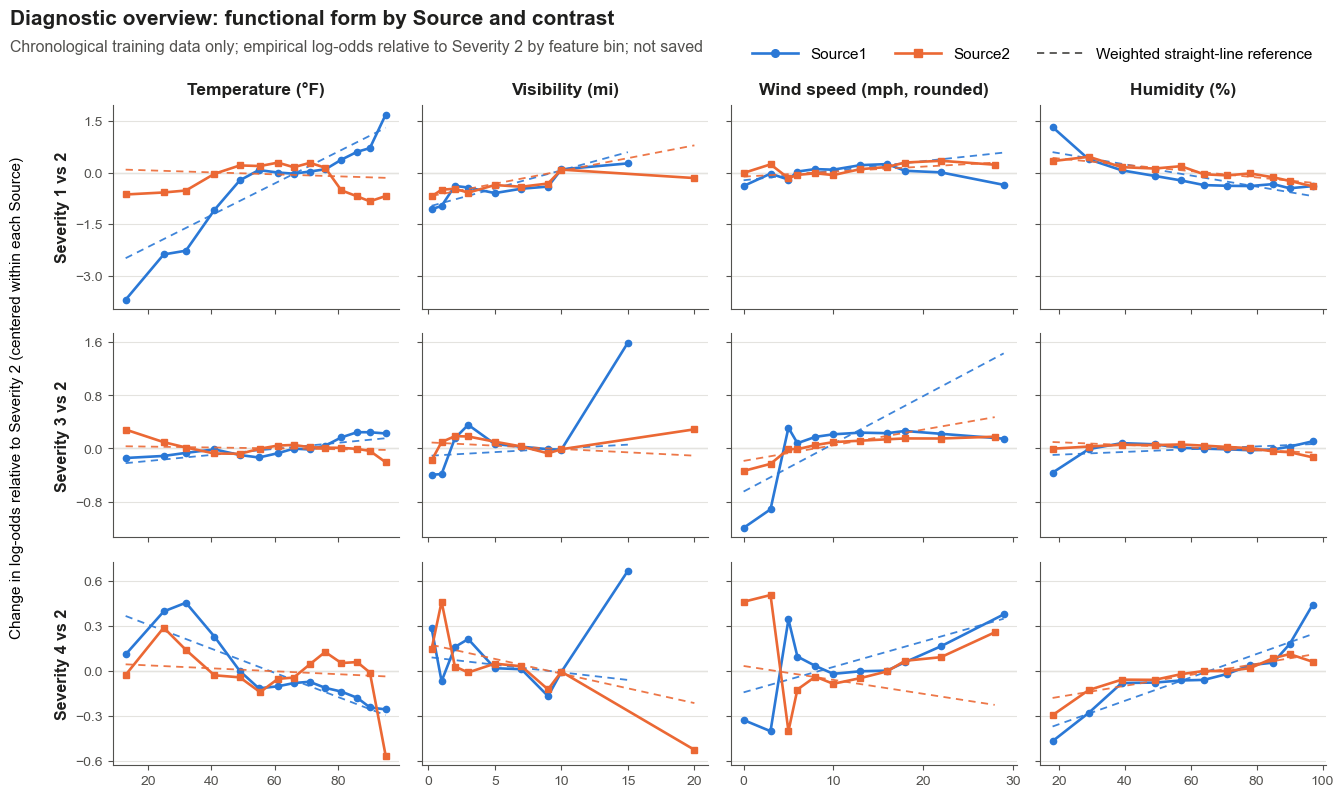

In [18]:
FIG2_STYLE = {
    "Source1": {"color": "#2a78d6", "marker": "o"},
    "Source2": {"color": "#eb6834", "marker": "s"},
}
FEATURE_XLIM = {"Visibility(mi)": (-0.5, 21)}
FIGURE_2_TITLES = {**FEATURES, WIND: "Wind speed (mph, rounded)"}
# Rounded wind (Section 6.5) replaces the unrounded wind bins in the figure only.
figure_stats = pd.concat([bin_stats.drop(index=WIND, level="feature"), wind_rounded_stats]).reindex(
    list(FEATURES), level="feature"
)

# Centre each Source x feature curve on that Source's overall log-odds for the same rows.
totals = figure_stats.groupby(level=["feature", "Source"])[SEVERITY_LEVELS].sum()
centre = {k: np.log((totals[k] + ZERO_CORRECTION) / (totals[2] + ZERO_CORRECTION)) for k in CONTRASTS}

with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(3, 4, figsize=(13.33, 8.0), sharex="col", sharey="row")
    for col, (feature, axis_label) in enumerate(FIGURE_2_TITLES.items()):
        for row, k in enumerate(CONTRASTS):
            ax = axes[row, col]
            ax.axhline(0, color="#c9c8c2", linewidth=0.9, zorder=0)
            for source in FIG2_SOURCES:
                part = figure_stats.loc[(feature, source)]
                shift = centre[k].loc[(feature, source)]
                x = part["representative"].to_numpy(float)
                ax.plot(x, part[f"line {k} vs 2"] - shift, color=FIG2_STYLE[source]["color"],
                        linestyle=(0, (4, 3)), linewidth=1.3, alpha=0.9)
                ax.plot(x, part[f"log-odds {k} vs 2"] - shift, linewidth=1.9, markersize=4.5, **FIG2_STYLE[source])
            ax.grid(axis="y", color="#e4e3df", linewidth=0.8)
            ax.set_axisbelow(True)
            ax.tick_params(labelsize=10)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            if feature in FEATURE_XLIM:
                ax.set_xlim(*FEATURE_XLIM[feature])
            if row == 0:
                ax.set_title(axis_label, fontsize=12.5, fontweight="bold", color="#1f1f1e", pad=8)
            if col == 0:
                ax.set_ylabel(f"Severity {k} vs 2", fontsize=11.5, fontweight="bold", color="#1f1f1e")

    fig.supylabel("Change in log-odds relative to Severity 2 (centered within each Source)", x=0.008, fontsize=11)
    fig.text(0.008, 0.985, "Diagnostic overview: functional form by Source and contrast",
             fontsize=15, fontweight="bold", color="#1f1f1e", va="top")
    fig.text(0.008, 0.948, "Chronological training data only; empirical log-odds relative to Severity 2 by feature bin; not saved",
             fontsize=11.5, color="#52514e", va="top")
    legend_handles = [
        Line2D([], [], linewidth=1.9, markersize=5.5, label=source, **FIG2_STYLE[source]) for source in FIG2_SOURCES
    ] + [Line2D([], [], color="#52514e", linestyle=(0, (4, 3)), linewidth=1.3, label="Weighted straight-line reference")]
    fig.legend(handles=legend_handles, loc="upper right", ncol=3, frameon=False, fontsize=11,
               bbox_to_anchor=(0.995, 0.955), handlelength=3.0, columnspacing=1.8)
    fig.subplots_adjust(left=0.085, right=0.995, top=0.865, bottom=0.04, hspace=0.12, wspace=0.08)

    plt.show()

**Diagnostic notes (all contrasts, both Sources).**

- **Temperature: nonlinear / curved, with threshold-like extremes.** *Data:* in Source2 a straight line captures almost none of the binned variation (weighted R² 0.02–0.03 for all three contrasts, log-odds ranges 0.49–1.12); the curves bend at the coldest and hottest bins. In Source1, Severity 4 vs 2 rises toward freezing and then falls with heat. *Interpretation:* a single linear temperature term is unlikely to represent these shapes.
- **Visibility: threshold-like.** *Data:* most rows sit at exactly 10 miles. The low-visibility bins and the above-10-mile bin depart from the straight line, which explains little of the Severity 3 vs 2 pattern (R² 0.04 in Source1, 0.18 in Source2). *Interpretation:* low-visibility ranges behave differently from the bulk; the above-10-mile bin is small (11,795 Source1 and 14,645 Source2 rows) and should not drive conclusions.
- **Wind speed: weak / unclear; not evidence of nonlinearity.** *Data:* before April 2019, 95.6% of wind values have decimals (0.0% after), so the unrounded bins mix the two periods unevenly and zigzag (Section 6.4). Rounded to whole mph (Section 6.5, diagnostic only), bins from 7 mph upward hold the same period mix (Source1 17.75–18.29% pre-2019 rows) and the zigzag disappears: Source1 Severity 3 vs 2 stays between −2.73 and −2.62. The low-wind bins still differ (calm 0.33% pre-2019 rows against 28.39% at 3–5 mph), so the step up from calm remains tied to the collection period, and the straight-line fit is unchanged (Source1 Severity 3 vs 2 weighted R² 0.485 raw and rounded). *Interpretation:* roughly flat above light winds; the apparent calm threshold is mostly a collection-period effect. *Modeling implication:* recording precision must not act as a proxy for collection period, so wind should enter any model at a common precision, with low-wind effects checked within one recording period.
- **Humidity: near-linear for Severity 4, weak for Severity 3.** *Data:* Severity 4 vs 2 has R² 0.81 (Source1) and 0.84 (Source2); Severity 3 vs 2 spans only 0.47 and 0.19. *Interpretation:* a linear humidity term looks plausible, apart from Source1's driest bin for Severity 1.
- **Source differences and ML implication.** *Data:* Source1's steepest curves are for Severity 1 and 3, the two levels it assigns only in limited years (Figure 1); for example, Source1 Severity 1 vs 2 rises with temperature (range 5.38) while Source2's does not (R² 0.02). *Interpretation:* within-Source time effects can still shape these curves, so pooled interpretation needs caution. The curvature and thresholds in temperature and visibility mean that transformations, bins/splines or tree-based models deserve evaluation alongside Multinomial Logistic Regression; for humidity a linear term remains plausible. No predictive model has been trained, so this does not show that tree models perform better.

### 6.7 Figure 2 (presentation)

**Question.** Is one linear term per continuous feature sufficient for Multinomial Logistic Regression?

The slide version shows one contrast for one provider: Severity 3 vs Severity 2 in Source2's chronological training rows. Source2 records Severity 3 throughout the training period and avoids mixing in the provider differences already covered by Figure 1. It shows three features: temperature, visibility and humidity. This is a focused functional-form view; the modeling target remains four-class Severity. The values are the binned log-odds and weighted straight lines already computed in Sections 6.2–6.3. For readability the visibility panel stops at 10 miles: the broad > 10 mi tail bin is not drawn, but it stays in the tables, and the dashed line is the same fit to all bins.

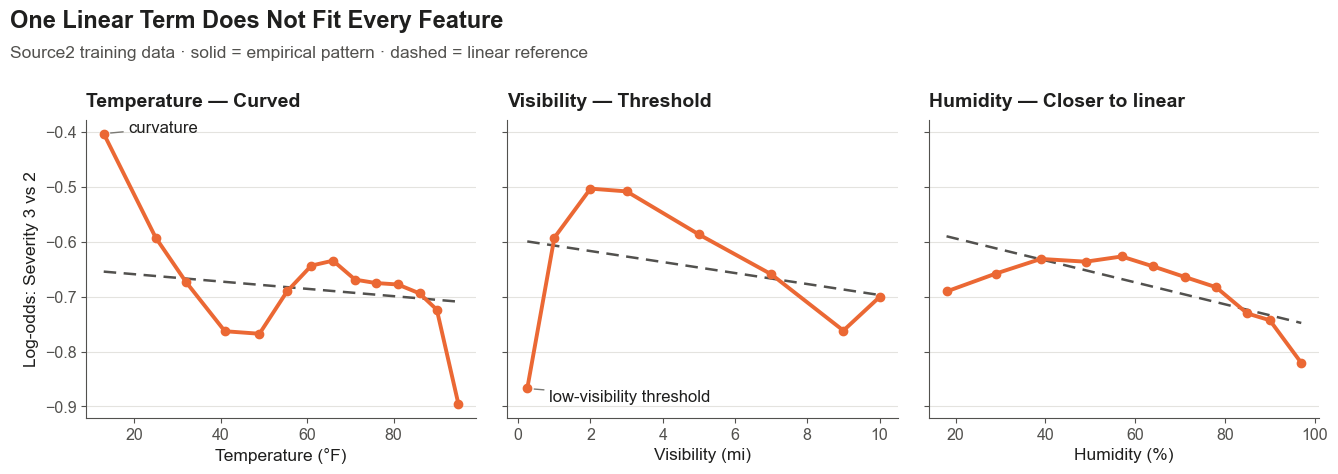

In [19]:
PRESENTATION_SOURCE = "Source2"
PRESENTATION_CONTRAST = 3
PRESENTATION_PANELS = [  # feature, conclusion title, x-axis label
    ("Temperature(F)", "Temperature — Curved", "Temperature (°F)"),
    ("Visibility(mi)", "Visibility — Threshold", "Visibility (mi)"),
    ("Humidity(%)", "Humidity — Closer to linear", "Humidity (%)"),
]
PANEL_NOTES = {  # one short note, attached to the first (lowest-value) bin
    "Temperature(F)": ("curvature", (18, 4)),
    "Visibility(mi)": ("low-visibility threshold", (16, -6)),
}
PRESENTATION_MAX_X = {"Visibility(mi)": 10}  # slide only: the broad > 10 mi tail bin stays in the tables
EMPIRICAL_COLOR = FIG2_STYLE[PRESENTATION_SOURCE]["color"]  # Source2's colour in Figure 1
REFERENCE_COLOR = "#52514e"

with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(1, 3, figsize=(13.33, 4.8), sharey=True)
    for ax, (feature, title, x_label) in zip(axes, PRESENTATION_PANELS):
        part = bin_stats.loc[(feature, PRESENTATION_SOURCE)]
        if feature in PRESENTATION_MAX_X:
            part = part[part["representative"] <= PRESENTATION_MAX_X[feature]]
        x = part["representative"].to_numpy(float)
        empirical = part[f"log-odds {PRESENTATION_CONTRAST} vs 2"].to_numpy(float)
        ax.plot(x, part[f"line {PRESENTATION_CONTRAST} vs 2"], color=REFERENCE_COLOR,
                linestyle=(0, (5, 3)), linewidth=1.8)
        ax.plot(x, empirical, color=EMPIRICAL_COLOR, linewidth=2.8, marker="o", markersize=6)
        if feature in PANEL_NOTES:
            note, offset = PANEL_NOTES[feature]
            ax.annotate(note, xy=(x[0], empirical[0]), xytext=offset, textcoords="offset points",
                        ha="left", va="center", fontsize=12, color="#1f1f1e",
                        arrowprops={"arrowstyle": "-", "color": "#7a7974", "linewidth": 1.0, "shrinkB": 5})
        ax.set_title(title, loc="left", fontsize=14, fontweight="bold", color="#1f1f1e", pad=10)
        ax.set_xlabel(x_label, fontsize=12.5)
        ax.grid(axis="y", color="#e4e3df", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=11.5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    axes[1].set_xlim(-0.3, 10.5)
    axes[1].set_xticks(range(0, 11, 2))
    axes[0].set_ylabel("Log-odds: Severity 3 vs 2", fontsize=12.5)
    axes[0].yaxis.set_major_locator(MaxNLocator(nbins=6))

    fig.text(0.008, 0.99, "One Linear Term Does Not Fit Every Feature",
             fontsize=17, fontweight="bold", color="#1f1f1e", va="top")
    fig.text(0.008, 0.915, "Source2 training data · solid = empirical pattern · dashed = linear reference",
             fontsize=12.5, color="#52514e", va="top")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.76, bottom=0.14, wspace=0.08)

    FIGURE_2_PATH = FIGURES_DIR / "ml_nonlinear_feature_severity.png"  # FIGURES_DIR = REPO_ROOT / "reports" / "figures"
    FIGURE_2_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_2_PATH, dpi=200, bbox_inches="tight", facecolor="white")  # overwrites any existing file
    assert FIGURE_2_PATH.is_file(), f"Figure 2 was not written to {FIGURE_2_PATH}"
    plt.show()

### Figure 2 interpretation

- **Temperature shows clear curvature**, so a single linear coefficient would miss part of the relationship (Source2 Severity 3 vs 2: weighted straight-line R² 0.03 across a log-odds range of 0.49).
- **Visibility shows threshold-like behavior**, which is naturally handled by binning, splines or tree-based models (R² 0.18; the lowest-visibility bin sits well below its neighbours).
- **Humidity is much closer to linear** (the bins deviate from the straight line by a weighted RMSE of 0.04 across a range of 0.19), showing that extra model complexity is not equally necessary for every feature.

**Modeling conclusion.** Multinomial Logistic Regression remains the baseline, but nonlinear transformations or tree-based models should be evaluated because some continuous predictors violate a simple linear-logit specification.

**Wind Speed note.** Wind Speed is omitted from the presentation figure because recording precision changes across collection periods; this must be standardized or handled before using it as modeling evidence (Sections 6.4–6.5).

### 6.8 Start_Hour as a cyclic feature

`Start_Hour` is not treated as a continuous linear predictor. For Source1 and Source2 in the training partition, the tables give the four-class shares by hour and then summarise the hourly log-odds against Severity 2:
- how much of the between-hour variation one sine/cosine pair (24-hour cycle) and two pairs (24- and 12-hour cycles) capture, as weighted R² against the 24 hourly values;
- the step from 23:00 to 00:00 compared with the typical hour-to-hour step, which tests whether the pattern is continuous around midnight.

The small plot is a notebook diagnostic and is not saved.

In [20]:
hour_counts = (
    weather[weather["Source"].isin(FIG2_SOURCES)]
    .groupby(["Source", "Start_Hour", "Severity"], observed=True).size()
    .unstack("Severity", fill_value=0).reindex(columns=SEVERITY_LEVELS, fill_value=0)
)
hour_rows = hour_counts.sum(axis=1)
hour_shares = 100 * hour_counts.div(hour_rows, axis=0)
hour_table = hour_shares.unstack("Source").swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
hour_table.columns = [f"{source} S{k} (%)" for source, k in hour_table.columns]
hour_table.round(2)

,Source1 S1 (%),Source1 S2 (%),Source1 S3 (%),Source1 S4 (%),Source2 S1 (%),Source2 S2 (%),Source2 S3 (%),Source2 S4 (%)
Start_Hour,,,,,,,,
0,0.40,87.04,4.38,8.18,0.06,52.31,46.18,1.45
1,0.35,89.78,3.73,6.14,0.03,53.97,44.48,1.52
2,0.38,88.76,4.12,6.73,0.09,52.09,46.25,1.57
3,0.42,86.47,5.33,7.77,0.09,53.41,45.04,1.46
4,0.54,86.62,5.04,7.80,0.12,69.55,29.41,0.92
5,0.68,87.30,5.34,6.68,0.12,68.93,30.35,0.59
6,0.78,88.18,5.63,5.41,0.10,70.56,28.99,0.35
7,0.82,88.65,5.65,4.87,0.13,74.01,25.62,0.24
8,0.92,87.98,6.00,5.10,0.13,74.74,24.94,0.20


hourly log-odds range  R², one sine/cosine pair  \
Source  contrast                                                           
Source1 Severity 1 vs 2                   1.29                      0.67   
        Severity 3 vs 2                   0.64                      0.01   
        Severity 4 vs 2                   0.84                      0.73   
Source2 Severity 1 vs 2                   1.21                      0.14   
        Severity 3 vs 2                   0.98                      0.70   
        Severity 4 vs 2                   2.44                      0.37   

                         R², two pairs  23:00 to 00:00 step  \
Source  contrast                                              
Source1 Severity 1 vs 2           0.94                 0.03   
        Severity 3 vs 2           0.76                 0.09   
        Severity 4 vs 2           0.86                 0.19   
Source2 Severity 1 vs 2           0.61                 0.01   
        Severity 3 vs 2           0.93                 0.07   
        Severity 4 vs 2           0.93                 0.05   

                         median hour-to-hour step  largest hour-to-hour step  
Source  contrast                                                              
Source1 Severity 1 vs 2                      0.12                       0.44  
        Severity 3 vs 2                      0.10                       0.28  
        Severity 4 vs 2                      0.11                       0.32  
Source2 Severity 1 vs 2                      0.17                       1.14  
        Severity 3 vs 2                      0.06                       0.69  
        Severity 4 vs 2                      0.21                       0.73

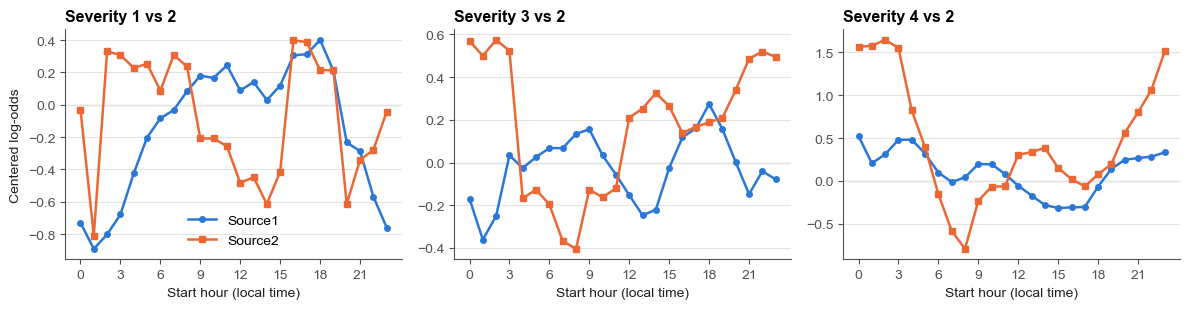

In [21]:
def harmonic_r2(hours: np.ndarray, y: np.ndarray, w: np.ndarray, n_pairs: int) -> float:
    """Weighted R² of sine/cosine terms with periods 24/1 ... 24/n_pairs hours."""
    angle = 2 * np.pi * hours / 24
    design = np.column_stack([np.ones_like(angle)] + [f(m * angle) for m in range(1, n_pairs + 1) for f in (np.sin, np.cos)])
    root_w = np.sqrt(w)
    coef, *_ = np.linalg.lstsq(design * root_w[:, None], y * root_w, rcond=None)
    residual_ss = np.sum(w * (y - design @ coef) ** 2)
    return 1 - residual_ss / np.sum(w * (y - np.average(y, weights=w)) ** 2)


hour_log_odds = {}
records = []
for source in FIG2_SOURCES:
    part = hour_counts.loc[source]
    hours = part.index.to_numpy(float)
    w = part.sum(axis=1).to_numpy(float)
    for k in CONTRASTS:
        y = np.log((part[k] + ZERO_CORRECTION) / (part[2] + ZERO_CORRECTION)).to_numpy(float)
        hour_log_odds[(source, k)] = y
        steps = np.abs(np.diff(y))
        records.append({
            "Source": source, "contrast": f"Severity {k} vs 2",
            "hourly log-odds range": y.max() - y.min(),
            "R², one sine/cosine pair": harmonic_r2(hours, y, w, 1),
            "R², two pairs": harmonic_r2(hours, y, w, 2),
            "23:00 to 00:00 step": abs(y[0] - y[-1]),
            "median hour-to-hour step": np.median(steps),
            "largest hour-to-hour step": steps.max(),
        })
hour_diagnostics = pd.DataFrame(records).set_index(["Source", "contrast"]).round(2)
display(hour_diagnostics)

with plt.rc_context(plot_rc):
    fig_h, axes_h = plt.subplots(1, 3, figsize=(12, 3.2), sharex=True)
    for ax, k in zip(axes_h, CONTRASTS):
        for source in FIG2_SOURCES:
            y = hour_log_odds[(source, k)]
            ax.plot(range(24), y - np.average(y, weights=hour_counts.loc[source].sum(axis=1)), linewidth=1.8,
                    markersize=4, label=source, **FIG2_STYLE[source])
        ax.axhline(0, color="#c9c8c2", linewidth=0.9, zorder=0)
        ax.set_title(f"Severity {k} vs 2", loc="left", fontsize=11.5, fontweight="bold")
        ax.set_xticks(range(0, 24, 3))
        ax.set_xlabel("Start hour (local time)")
        ax.grid(axis="y", color="#e4e3df", linewidth=0.8)
    axes_h[0].set_ylabel("Centered log-odds")
    axes_h[0].legend(frameon=False, fontsize=10)
    fig_h.tight_layout()
    plt.show()

**Start_Hour conclusion: represent it as categorical (24 levels).** *Data:* every pattern is continuous across midnight (23:00 to 00:00 steps of 0.01–0.19 against median hour-to-hour steps of 0.06–0.21), so hour is cyclic. One sine/cosine pair captures as little as R² 0.01 (Source1, Severity 3 vs 2) and two pairs reach 0.61–0.94. Source2 also has a sharp step between 03:00 and 04:00, where its Severity 3 share falls from 45.04% to 29.41%. *Interpretation:* smooth cyclical terms would miss these steps; 24 categories capture any hourly shape at negligible cost with 6.2 million training rows. Cyclical encoding remains a fallback if a compact representation is needed.

## 7. Figure 3: Geographic shift (optional, not implemented)

Only if time permits after Figures 1 and 2.

- **Question:** do Census regions differ in their Severity distribution enough to add information beyond the temporal shift?
- **Planned method:** each `Region`'s Severity distribution compared with the rest of the data, alongside the train/holdout difference.
- **Decision it informs:** whether region-level evaluation is needed.